# Cleaning Fraud Labels Data

In [508]:
import pandas as pd

fraud_labels = pd.read_csv("data/raw/fraud_labels.csv")
fraud_labels

,transaction_id,is_fraud,fraud_reason
0,1,0,NaN
1,2,0,NaN
2,3,0,NaN
3,4,0,NaN
4,5,0,NaN
...,...,...,...
999995,999996,0,NaN
999996,999997,0,NaN
999997,999998,0,NaN
999998,999999,0,NaN


In [509]:
fraud_labels.info()

fraud_labels.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   transaction_id  1000000 non-null  int64 
 1   is_fraud        1000000 non-null  int64 
 2   fraud_reason    24260 non-null    object
dtypes: int64(2), object(1)
memory usage: 22.9+ MB


,transaction_id,is_fraud,fraud_reason
count,1000000.000000,1000000.000000,24260
unique,NaN,NaN,33
top,NaN,NaN,nan
freq,NaN,NaN,6034
mean,499999.788612,0.006389,NaN
std,288677.403098,0.079676,NaN
min,1.000000,0.000000,NaN
25%,249990.750000,0.000000,NaN
50%,500018.500000,0.000000,NaN
75%,750002.250000,0.000000,NaN


In [510]:
# Check fraud distribution
fraud_labels['is_fraud'].value_counts()

is_fraud
0    993611
1      6389
Name: count, dtype: int64

In [511]:
# Missing values
fraud_labels.isnull().sum()

transaction_id         0
is_fraud               0
fraud_reason      975740
dtype: int64

In [512]:
# Non-fraud transactions with a fraud reason
invalid_1 = fraud_labels[(fraud_labels['is_fraud'] == 0) & (fraud_labels['fraud_reason'].notna())]

# Fraud transactions without a fraud reason
invalid_2 = fraud_labels[(fraud_labels['is_fraud'] == 1) & (fraud_labels['fraud_reason'].isna())]

print(len(invalid_1))
print(len(invalid_2))

17902
31


In [513]:
#handling missing values
fraud_labels.loc[
(fraud_labels['is_fraud'] == 1) & (fraud_labels['fraud_reason'].isna()),
'fraud_reason'
] = 'Unknown'

In [514]:
#keep NaN or replace with a label
fraud_labels['fraud_reason'] = fraud_labels['fraud_reason'].fillna('No Fraud')

In [515]:
# removing duplicates
fraud_labels = fraud_labels.drop_duplicates()

fraud_labels[fraud_labels.duplicated() == True]


,transaction_id,is_fraud,fraud_reason


In [516]:
# ensuring ID's unique
fraud_labels['transaction_id'].nunique()

fraud_labels.shape[0]

999059

In [517]:
# finding duplicates
"fraud_labels.duplicated()"

'fraud_labels.duplicated()'

In [518]:
# correcting data types
fraud_labels['transaction_id'] = fraud_labels['transaction_id'].astype(float)
fraud_labels['is_fraud'] = fraud_labels['is_fraud'].astype(float)
fraud_labels.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999059 entries, 0 to 999999
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   transaction_id  999059 non-null  float64
 1   is_fraud        999059 non-null  float64
 2   fraud_reason    999059 non-null  object 
dtypes: float64(2), object(1)
memory usage: 30.5+ MB


C:\Users\E1023397\AppData\Local\Temp\ipykernel_31668\3959015426.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fraud_labels['transaction_id'] = fraud_labels['transaction_id'].astype(float)
C:\Users\E1023397\AppData\Local\Temp\ipykernel_31668\3959015426.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fraud_labels['is_fraud'] = fraud_labels['is_fraud'].astype(float)


In [519]:
# standardazing
fraud_labels['fraud_reason'] = (
fraud_labels['fraud_reason']
.str.strip()
.str.lower()
)
fraud_labels

C:\Users\E1023397\AppData\Local\Temp\ipykernel_31668\3426566504.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fraud_labels['fraud_reason'] = (


,transaction_id,is_fraud,fraud_reason
0,1.0,0.0,no fraud
1,2.0,0.0,no fraud
2,3.0,0.0,no fraud
3,4.0,0.0,no fraud
4,5.0,0.0,no fraud
...,...,...,...
999995,999996.0,0.0,no fraud
999996,999997.0,0.0,no fraud
999997,999998.0,0.0,no fraud
999998,999999.0,0.0,no fraud


In [520]:
# Validation
print(fraud_labels.isnull().sum())
print(fraud_labels['is_fraud'].value_counts())

# Check for invalid combinations again
fraud_labels[
((fraud_labels['is_fraud'] == 0) & (fraud_labels['fraud_reason'] != 'No Fraud'))
]

transaction_id    0
is_fraud          0
fraud_reason      0
dtype: int64
is_fraud
0.0    992670
1.0      6389
Name: count, dtype: int64


,transaction_id,is_fraud,fraud_reason
0,1.0,0.0,no fraud
1,2.0,0.0,no fraud
2,3.0,0.0,no fraud
3,4.0,0.0,no fraud
4,5.0,0.0,no fraud
...,...,...,...
999995,999996.0,0.0,no fraud
999996,999997.0,0.0,no fraud
999997,999998.0,0.0,no fraud
999998,999999.0,0.0,no fraud


In [521]:
fraud_labels.to_csv("Data/processed/fraud_label_cleaned.csv", index=False)

# Cleaning Merchants Data

In [522]:
import pandas as pd

merchants = pd.read_csv("data/raw/merchants.csv")
merchants.info()
merchants

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   merchant_id        20000 non-null  int64 
 1   merchant_name      20000 non-null  object
 2   merchant_category  19881 non-null  object
 3   province           20000 non-null  object
 4   city               19878 non-null  object
 5   risk_rating        19869 non-null  object
dtypes: int64(1), object(5)
memory usage: 937.6+ KB


,merchant_id,merchant_name,merchant_category,province,city,risk_rating
0,1,merchant 00001,Online Services,Free State,Bethlehem,Low
1,2,Merchant 00002,Grocery,Mpumalanga,Secunda,Low
2,3,Merchant 00003,Clothing,Limpopo,Polokwane,Medium
3,4,Merchant 00004,Grocery,Mpumalanga,Mbombela,Low
4,5,Merchant 00005,Travel,Free State,Bloemfontein,Medium
...,...,...,...,...,...,...
19995,19996,Merchant 19996,Online Services,Mpumalanga,Mbombela,Low
19996,19997,Merchant 19997,Restaurant,KwaZulu-Natal,Durban,Low
19997,19998,Merchant 19998,Grocery,KwaZulu-Natal,Richards Bay,Low
19998,19999,Merchant 19999,Grocery,Free State,Welkom,Low


In [523]:
# #This helps identify spelling inconsistencies.

merchants.city = merchants.city.str.strip()
# # merchants the white and space bar space
merchants['city'] = merchants['city'].str.replace(r'\s+', ' ', regex= True)
merchants.city = merchants.city.str.title()

# merchants.city.unique()

merchants.city.unique()

array(['Bethlehem', 'Secunda', 'Polokwane', 'Mbombela', 'Bloemfontein',
       'Pietermaritzburg', 'Johannesburg', 'Gqeberha', 'Klerksdorp',
       'Stellenbosch', 'Welkom', 'Rustenburg', 'Mahikeng', 'Thohoyandou',
       'Emalahleni', 'Durban', 'Midrand', 'Richards Bay', 'East London',
       'Pretoria', 'Upington', 'Mthatha', 'George', 'Paarl', 'Soweto',
       'Kimberley', 'Tzaneen', nan, 'Kuruman', 'Cape Town'], dtype=object)

In [524]:
merchants.province= merchants.province.str.strip()
# # merchants the white and space bar space
merchants['province'] = merchants['province'].str.replace("  ", " ")
merchants.province = merchants.province.str.title()


# #Expected provinces
merchants.province.unique()

array(['Free State', 'Mpumalanga', 'Limpopo', 'Kwazulu-Natal', 'Gauteng',
       'Eastern Cape', 'North West', 'Western Cape', 'Northern Cape'],
      dtype=object)

In [525]:
merchants.merchant_category= merchants.merchant_category.str.strip()
# # merchants the white and space bar space
merchants['merchant_category'] = merchants['merchant_category'].str.replace("  ", " ")
merchants.merchant_category = merchants.merchant_category.str.title()
merchants.merchant_category.unique()


array(['Online Services', 'Grocery', 'Clothing', 'Travel',
       'Entertainment', 'Fuel', 'Healthcare', 'Electronics', 'Other',
       'Restaurant', nan], dtype=object)

In [526]:
merchants.risk_rating= merchants.risk_rating.str.strip()
# # merchants the white and space bar space
merchants['risk_rating'] = merchants['risk_rating'].str.replace("  ", " ")
merchants.risk_rating = merchants.risk_rating.str.title()
merchants.risk_rating.unique()


array(['Low', 'Medium', 'High', 'Critical', 'High Risk', nan, 'Unknown'],
      dtype=object)

In [527]:
# replacing null values with"Nan"
import numpy as np
merchants = merchants.replace(np.nan, "Nan")

In [528]:
merchants.isnull().sum()

merchant_id          0
merchant_name        0
merchant_category    0
province             0
city                 0
risk_rating          0
dtype: int64

In [529]:
# Showing the entire row duplicates
merchants.duplicated().sum()

# since the merchant id are unique
merchants['merchant_id'].duplicated().sum()

#viewing duplicates
merchants[merchants['merchant_id'].duplicated(keep=False)]

,merchant_id,merchant_name,merchant_category,province,city,risk_rating


In [530]:
# Removing the duplicates
merchants = merchants.drop_duplicates()

merchants[merchants.duplicated() == True]


,merchant_id,merchant_name,merchant_category,province,city,risk_rating


In [531]:
merchants.province = merchants.province.str.replace(r'\s+', ' ', regex=True)
merchants.province.unique()

array(['Free State', 'Mpumalanga', 'Limpopo', 'Kwazulu-Natal', 'Gauteng',
       'Eastern Cape', 'North West', 'Western Cape', 'Northern Cape'],
      dtype=object)

In [532]:
print(merchants.info())
print(merchants.isnull().sum())
print(merchants.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   merchant_id        20000 non-null  int64 
 1   merchant_name      20000 non-null  object
 2   merchant_category  20000 non-null  object
 3   province           20000 non-null  object
 4   city               20000 non-null  object
 5   risk_rating        20000 non-null  object
dtypes: int64(1), object(5)
memory usage: 937.6+ KB
None
merchant_id          0
merchant_name        0
merchant_category    0
province             0
city                 0
risk_rating          0
dtype: int64
0


In [533]:
merchants.to_csv("Data/processed/merchants_cleaned.csv", index=False)

# Date Feature Engineering

In [534]:
# Convert to datetime first
import pandas as pd

customers = pd.read_csv("data/processed/cleanedCustomers2.csv")
customers
#customers['transaction_date'] == pd.to_datetime(customers['transaction_date'])


,Unnamed: 0,customer_id,first_name,last_name,age,province,city,employment_status,income,customer_since
0,0,1,Emma,Naidoo,42,Free State,Bloemfontein,Employed,11418.82,2022-11-24
1,1,2,Amelia,Mokoena,49,Mpumalanga,Mbombela,Nan,31336.45,2024-12-25
2,2,3,Nomsa,Jacobs,34,North West,Rustenburg,Employed,11351.46,2020-03-18
3,3,4,Sipho,Dlamini,35,Kwazulu-Natal,Durban,Retired,30291.15,2025-10-21
4,4,5,Emma,Molefe,33,Kwazulu-Natal,Durban,Employed,28803.42,2013-10-02
...,...,...,...,...,...,...,...,...,...,...
100085,100388,40659,Sophia,Botha,39,Eastern Cape,Gqeberha,Employed,15477.05,2025-02-03
100086,100390,93542,Noah,Jacobs,41,Gauteng,Johannesburg,Student,0.00,2016-12-26
100087,100392,89556,Lerato,Botha,33,Kwazulu-Natal,Durban,Unemployed,21132.74,2021-08-28
100088,100393,55437,Noah,Botha,56,Gauteng,Soweto,Retired,31652.89,2016-08-19


In [535]:
#Converting customer_since data type to datetime and fixing date format
#customers['customer_since'] = customer['customer-since'].str.replace("-","/")

customers['customer_since'] = pd.to_datetime(customers['customer_since'],
format='mixed',
errors='coerce')


In [536]:
customers['Start_Year'] = customers.customer_since.dt.year
customers

,Unnamed: 0,customer_id,first_name,last_name,age,province,city,employment_status,income,customer_since,Start_Year
0,0,1,Emma,Naidoo,42,Free State,Bloemfontein,Employed,11418.82,2022-11-24,2022
1,1,2,Amelia,Mokoena,49,Mpumalanga,Mbombela,Nan,31336.45,2024-12-25,2024
2,2,3,Nomsa,Jacobs,34,North West,Rustenburg,Employed,11351.46,2020-03-18,2020
3,3,4,Sipho,Dlamini,35,Kwazulu-Natal,Durban,Retired,30291.15,2025-10-21,2025
4,4,5,Emma,Molefe,33,Kwazulu-Natal,Durban,Employed,28803.42,2013-10-02,2013
...,...,...,...,...,...,...,...,...,...,...,...
100085,100388,40659,Sophia,Botha,39,Eastern Cape,Gqeberha,Employed,15477.05,2025-02-03,2025
100086,100390,93542,Noah,Jacobs,41,Gauteng,Johannesburg,Student,0.00,2016-12-26,2016
100087,100392,89556,Lerato,Botha,33,Kwazulu-Natal,Durban,Unemployed,21132.74,2021-08-28,2021
100088,100393,55437,Noah,Botha,56,Gauteng,Soweto,Retired,31652.89,2016-08-19,2016


In [537]:
customers['Start_Month'] = customers.customer_since.dt.month

In [538]:
customers['Start_Day'] = customers.customer_since.dt.day

In [539]:
customers['Weekday'] = customers.customer_since.dt.weekday
customers
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100090 entries, 0 to 100089
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Unnamed: 0         100090 non-null  int64         
 1   customer_id        100090 non-null  int64         
 2   first_name         100090 non-null  object        
 3   last_name          100090 non-null  object        
 4   age                100090 non-null  int64         
 5   province           100090 non-null  object        
 6   city               100090 non-null  object        
 7   employment_status  100090 non-null  object        
 8   income             100090 non-null  float64       
 9   customer_since     100090 non-null  datetime64[ns]
 10  Start_Year         100090 non-null  int32         
 11  Start_Month        100090 non-null  int32         
 12  Start_Day          100090 non-null  int32         
 13  Weekday            100090 non-null  int32   

In [540]:
customers.to_csv("cleanedCustomers2.csv", index=False)

# Fraud Features

In [541]:
import pandas as pd

In [542]:
accounts = pd.read_csv("data/processed/cleanedAccounts2.csv")
transactions = pd.read_csv("data/processed/transactions_clean_final3.csv")



In [543]:
accounts = accounts.account_id.astype(str)

In [544]:
trans_acc = pd.merge(accounts,transactions, how='inner')


In [545]:
trans_acc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 994216 entries, 0 to 994215
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   account_id           994216 non-null  object 
 1   Unnamed: 0           994216 non-null  int64  
 2   transaction_id       994216 non-null  int64  
 3   merchant_id          964779 non-null  object 
 4   transaction_date     994216 non-null  object 
 5   transaction_type     994216 non-null  object 
 6   channel              994216 non-null  object 
 7   amount               994216 non-null  float64
 8   currency             994216 non-null  object 
 9   description          994216 non-null  object 
 10  is_high_transaction  994216 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(7)
memory usage: 76.8+ MB


In [546]:
pd.DataFrame(trans_acc.groupby("account_id")['account_id'].count())
pd.DataFrame(trans_acc.groupby("account_id")['amount'].sum())


,amount
account_id,
1,14227.60
10,3558.06
100,23835.02
1000,12908.30
10000,8214.49
...,...
99995,5686.28
99996,4937.56
99997,10202.72


In [547]:
trans_acc = pd.merge(customers,transactions, how='inner')

In [548]:
trans_acc['customer_average'] = trans_acc.groupby('customer_id')['amount'].transform('mean')
transactions.info()

trans_acc['amount_vs_customer_average'] = (
trans_acc['amount'] / trans_acc['customer_average']
)
transactions


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001065 entries, 0 to 1001064
Data columns (total 11 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   Unnamed: 0           1001065 non-null  int64  
 1   transaction_id       1001065 non-null  int64  
 2   account_id           1001065 non-null  object 
 3   merchant_id          971403 non-null   object 
 4   transaction_date     1001065 non-null  object 
 5   transaction_type     1001065 non-null  object 
 6   channel              1001065 non-null  object 
 7   amount               1001065 non-null  float64
 8   currency             1001065 non-null  object 
 9   description          1001065 non-null  object 
 10  is_high_transaction  1001065 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(7)
memory usage: 77.3+ MB


,Unnamed: 0,transaction_id,account_id,merchant_id,transaction_date,transaction_type,channel,amount,currency,description,is_high_transaction
0,0,1,65820,19009.0,2025-05-26,Deposit,Pos,448.44,R,Transfer,False
1,1,2,9167,15505.0,2026-05-06,Purchase,Atm,85.00,R,Online purchase,False
2,2,3,86080,12053.0,2025-12-24,Payment,Atm,459.94,R,Retail purchase,False
3,3,4,56039,10816.0,2025-10-05,Transfer,Mobile,511.36,R,Bill payment,False
4,4,5,69271,9603.0,2025-01-27,Deposit,Mobile,362.61,R,Bill payment,False
...,...,...,...,...,...,...,...,...,...,...,...
1001060,1002984,554267,41324,17708.0,2025-05-08,Payment,Pos,156.88,R,Transfer,False
1001061,1002989,321736,13591,NaN,2026-07-24,Purchase,Mobile,1438.58,R,Online purchase,False
1001062,1002990,341329,58456,14524.0,2025-02-05,Deposit,Atm,1017.77,R,Bill payment,False
1001063,1002997,210561,42406,4358.0,2025-10-31,Withdrawal,Pos,189.00,R,Online purchase,False


# Customer Analytics

In [549]:
import pandas as pd

customers = pd.read_csv("data/final/customers_final.csv")
customers

,customer_id,first_name,last_name,age,province,city,employment_status,income,customer_since,Start_Year,Start_Month,Start_Day,Weekday,cus_trans_count,cus_total_trans_val,customer_avg_trans,cus_max_trans
0,1,Emma,Naidoo,42,Free State,Bloemfontein,Employed,11418.82,2022-11-24,2022,11,24,3,20.0,17160.30,858.015000,3553.98
1,2,Amelia,Mokoena,49,Mpumalanga,Mbombela,Nan,31336.45,2024-12-25,2024,12,25,2,15.0,14705.83,980.388667,2131.47
2,3,Nomsa,Jacobs,34,North West,Rustenburg,Employed,11351.46,2020-03-18,2020,3,18,2,8.0,7736.72,967.090000,1772.57
3,4,Sipho,Dlamini,35,Kwazulu-Natal,Durban,Retired,30291.15,2025-10-21,2025,10,21,1,42.0,32623.01,776.738333,2430.00
4,5,Emma,Molefe,33,Kwazulu-Natal,Durban,Employed,28803.42,2013-10-02,2013,10,2,2,12.0,9224.98,768.748333,1917.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100085,40659,Sophia,Botha,39,Eastern Cape,Gqeberha,Employed,15477.05,2025-02-03,2025,2,3,0,56.0,57030.38,1018.399643,3517.65
100086,93542,Noah,Jacobs,41,Gauteng,Johannesburg,Student,0.00,2016-12-26,2016,12,26,0,28.0,32166.68,1148.810000,4132.44
100087,89556,Lerato,Botha,33,Kwazulu-Natal,Durban,Unemployed,21132.74,2021-08-28,2021,8,28,5,NaN,NaN,NaN,NaN
100088,55437,Noah,Botha,56,Gauteng,Soweto,Retired,31652.89,2016-08-19,2016,8,19,4,NaN,NaN,NaN,NaN


In [550]:
#How many customers does the bank have?
total_customers =customers['customer_id'].nunique()
print(f"Total customers: {total_customers}")

Total customers: 99903


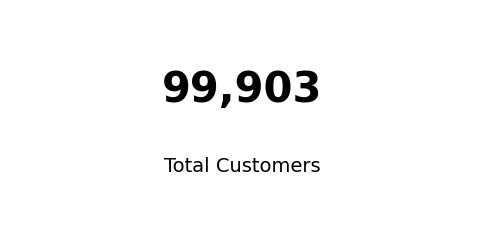

In [551]:
import matplotlib.pyplot as plt

total_customers = trans_acc['customer_id'].nunique()

fig, ax = plt.subplots(figsize=(6,3))
ax.axis('off')

ax.text(
    0.5, 0.6,
    f'{total_customers:,}',
    fontsize=30,
    fontweight='bold',
    ha='center'
)

ax.text(
0.5, 0.3,
'Total Customers',
fontsize=14,
ha='center'
)

plt.show()

In [552]:
#Which province has the most customers?
province_customers = (
trans_acc.groupby('province')['customer_id'].nunique().sort_values(ascending=False)
)
print(province_customers)
print("Province with most customers:", province_customers.idxmax())

province
Gauteng          29831
Kwazulu-Natal    20064
Western Cape     11945
Eastern Cape     10102
Limpopo           7938
Free State        6040
Mpumalanga        5987
North West        5077
Northern Cape     3004
Name: customer_id, dtype: int64
Province with most customers: Gauteng


In [553]:
g = list(province_customers.index.values)[0:]
v = list(province_customers.values)[0:]
g

['Gauteng',
 'Kwazulu-Natal',
 'Western Cape',
 'Eastern Cape',
 'Limpopo',
 'Free State',
 'Mpumalanga',
 'North West',
 'Northern Cape']

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Gauteng'),
  Text(1, 0, 'Kwazulu-Natal'),
  Text(2, 0, 'Western Cape'),
  Text(3, 0, 'Eastern Cape'),
  Text(4, 0, 'Limpopo'),
  Text(5, 0, 'Free State'),
  Text(6, 0, 'Mpumalanga'),
  Text(7, 0, 'North West'),
  Text(8, 0, 'Northern Cape')])

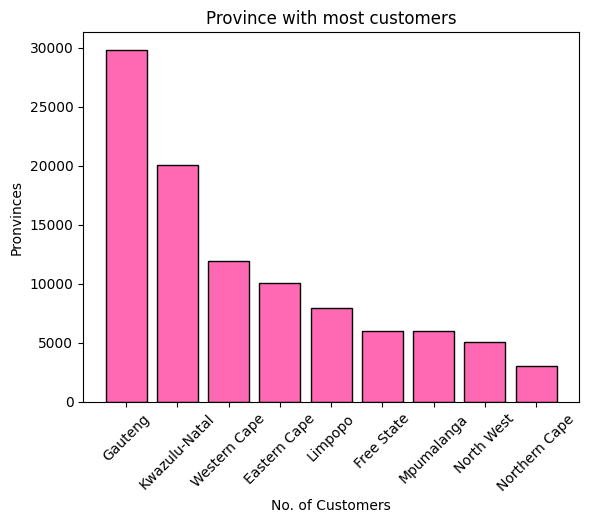

In [554]:
import matplotlib.pyplot as plt

# create bar graph
plt.bar(g, v, color="hotpink", edgecolor='black')

# formatting
plt.title('Province with most customers')
plt.xlabel('No. of Customers')
plt.ylabel('Pronvinces')
plt.xticks(rotation=45) 

In [555]:
import pandas as pd

accounts = pd.read_csv("data/processed/cleanedAccounts2.csv")
accounts

,account_id,customer_id,account_type,branch_id,account_status,opened_date
0,1,74688,Business,150,Active,2017-06-28
1,2,21183,Savings,54,Active,2021-01-26
2,3,93719,Cheque,164,Active,2023-01-13
3,4,6909,Cheque,36,Active,2017-12-30
4,5,45524,Cheque,86,Active,2021-02-21
...,...,...,...,...,...,...
124396,44719,0,Cheque,195,Active,2022-02-17
124397,75601,43076,Business,115,Nan,2023-12-15
124398,38511,65749,Nan,142,Active,2016-12-05
124399,55160,20760,Nan,72,Active,2023-09-19


In [556]:
# Which account type is most popular:
account_type = (
accounts.groupby('account_type')['customer_id'].nunique().sort_values(ascending=False)
)
print(account_type)
print("Most popular account type:", account_type.idxmax())


account_type
Savings     40564
Cheque      39068
Credit      11642
Business     9563
Nan           654
Name: customer_id, dtype: int64
Most popular account type: Savings


In [557]:
g = list(account_type.index.values)[0:3]
v = list(account_type.values)[0:3]
g

['Savings', 'Cheque', 'Credit']

Text(0, 0.5, 'Account type')

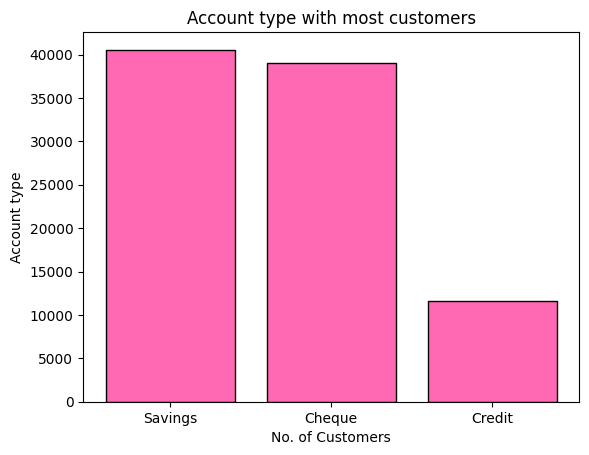

In [558]:
import matplotlib.pyplot as plt

# create bar graph
plt.bar(g, v, color='hotpink', edgecolor='black')

# formatting
plt.title('Account type with most customers')
plt.xlabel('No. of Customers')
plt.ylabel('Account type')

In [559]:
#Which age group has the highest transaction activity?
#Was creating age groups:
trans_acc['age_group'] = pd.cut(
trans_acc['age'],
bins=[0, 25, 35, 45, 55, 65, 100],
labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
)

#By number of transactions:
activity = trans_acc.groupby('age_group').size().sort_values(ascending=False)
print(activity)
print("Highest transaction activity:", activity.idxmax())

#By number of transactions:
activity = trans_acc.groupby('age_group').size().sort_values(ascending=False)
print(activity)
print("Highest transaction activity:", activity.idxmax())

age_group
36-45    29894
26-35    24455
46-55    20657
18-25    14780
56-65     8054
65+       2093
dtype: int64
Highest transaction activity: 36-45
age_group
36-45    29894
26-35    24455
46-55    20657
18-25    14780
56-65     8054
65+       2093
dtype: int64
Highest transaction activity: 36-45


C:\Users\E1023397\AppData\Local\Temp\ipykernel_31668\3347033155.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  activity = trans_acc.groupby('age_group').size().sort_values(ascending=False)
C:\Users\E1023397\AppData\Local\Temp\ipykernel_31668\3347033155.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  activity = trans_acc.groupby('age_group').size().sort_values(ascending=False)


In [560]:
import pandas as pd

customers = pd.read_csv("data/final/customers_final.csv")
customers

,customer_id,first_name,last_name,age,province,city,employment_status,income,customer_since,Start_Year,Start_Month,Start_Day,Weekday,cus_trans_count,cus_total_trans_val,customer_avg_trans,cus_max_trans
0,1,Emma,Naidoo,42,Free State,Bloemfontein,Employed,11418.82,2022-11-24,2022,11,24,3,20.0,17160.30,858.015000,3553.98
1,2,Amelia,Mokoena,49,Mpumalanga,Mbombela,Nan,31336.45,2024-12-25,2024,12,25,2,15.0,14705.83,980.388667,2131.47
2,3,Nomsa,Jacobs,34,North West,Rustenburg,Employed,11351.46,2020-03-18,2020,3,18,2,8.0,7736.72,967.090000,1772.57
3,4,Sipho,Dlamini,35,Kwazulu-Natal,Durban,Retired,30291.15,2025-10-21,2025,10,21,1,42.0,32623.01,776.738333,2430.00
4,5,Emma,Molefe,33,Kwazulu-Natal,Durban,Employed,28803.42,2013-10-02,2013,10,2,2,12.0,9224.98,768.748333,1917.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100085,40659,Sophia,Botha,39,Eastern Cape,Gqeberha,Employed,15477.05,2025-02-03,2025,2,3,0,56.0,57030.38,1018.399643,3517.65
100086,93542,Noah,Jacobs,41,Gauteng,Johannesburg,Student,0.00,2016-12-26,2016,12,26,0,28.0,32166.68,1148.810000,4132.44
100087,89556,Lerato,Botha,33,Kwazulu-Natal,Durban,Unemployed,21132.74,2021-08-28,2021,8,28,5,NaN,NaN,NaN,NaN
100088,55437,Noah,Botha,56,Gauteng,Soweto,Retired,31652.89,2016-08-19,2016,8,19,4,NaN,NaN,NaN,NaN


In [561]:
g = list(activity.index.values)[0:]
v = list(activity.values)[0:]
g

['36-45', '26-35', '46-55', '18-25', '56-65', '65+']

In [562]:
#Which employment group has the highest average income?
avg_income = (
trans_acc.groupby('employment_status')['income']
.mean()
.sort_values(ascending=False)
)
print(avg_income)
print("Highest average income:", avg_income.idxmax())

employment_status
Retired          26408.372536
Employed         26383.996189
Self-employed    26379.438914
Student          26293.854490
Nan              26272.111514
Unemployed       26189.167557
Name: income, dtype: float64
Highest average income: Retired


Text(0, 0.5, 'Activity')

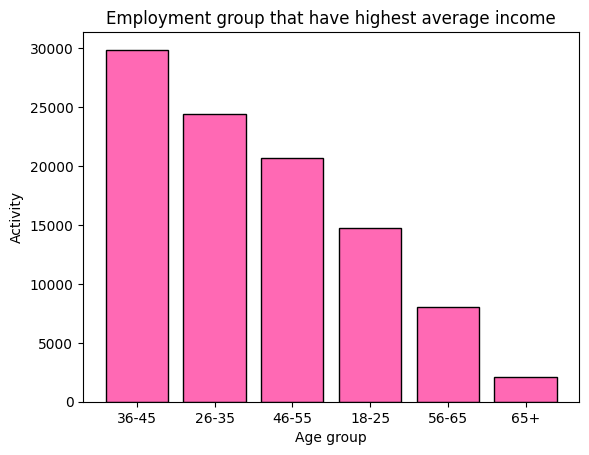

In [563]:
import matplotlib.pyplot as plt

# create bar graph
plt.bar(g, v, color='hotpink', edgecolor='black')

# formatting
plt.title('Employment group that have highest average income')
plt.xlabel('Age group')
plt.ylabel('Activity')

In [564]:

# Which customer segments generate the highest transaction value
bins = [0, 10000, 30000, 60000, float('inf')]
labels = ['Low Income', 'Middle Income', 'High Income', 'Very High Income']

customers['customer_segment'] = pd.cut(
    customers['income'],
    bins=bins,
    labels=labels
)

segment_value = customers.groupby('customer_segment')['cus_total_trans_val'].sum().sort_values(ascending=False).reset_index()#

print(segment_value)

   customer_segment  cus_total_trans_val
0     Middle Income         4.365035e+09
1       High Income         1.551074e+09
2        Low Income         8.146618e+08
3  Very High Income         4.148204e+08


C:\Users\E1023397\AppData\Local\Temp\ipykernel_31668\2441187171.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_value = customers.groupby('customer_segment')['cus_total_trans_val'].sum().sort_values(ascending=False).reset_index()#


In [565]:
g = list(segment_value.index.values)[0:]
v = list(segment_value.values)[0:]
g

[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

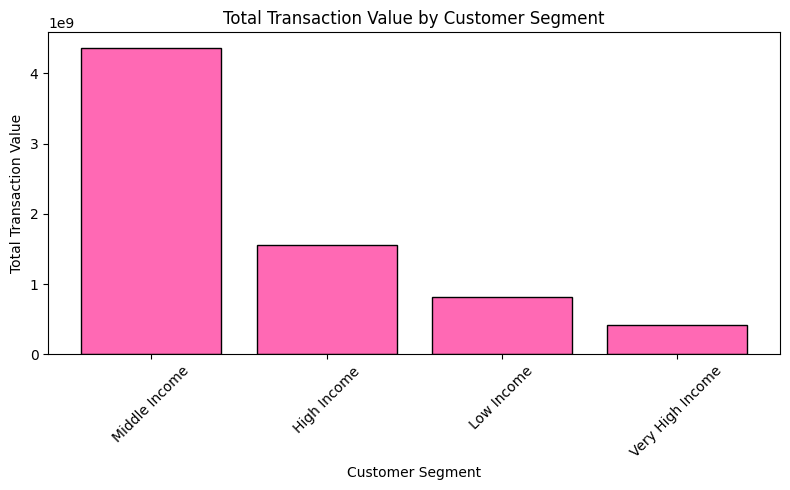

In [566]:
import matplotlib.pyplot as plt

# Create bar graph
plt.figure(figsize=(8, 5))
plt.bar(
segment_value['customer_segment'],
segment_value['cus_total_trans_val'],
color='hotpink', edgecolor='black'
)

# Formatting
plt.title('Total Transaction Value by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Transaction Value')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [567]:
customers.to_csv("customer_final.csv", index=False)

In [568]:
import pandas as pd
customers = pd.read_csv("customer_final.csv")
customers.head()

,customer_id,first_name,last_name,age,province,city,employment_status,income,customer_since,Start_Year,Start_Month,Start_Day,Weekday,cus_trans_count,cus_total_trans_val,customer_avg_trans,cus_max_trans,customer_segment
0,1,Emma,Naidoo,42,Free State,Bloemfontein,Employed,11418.82,2022-11-24,2022,11,24,3,20.0,17160.30,858.015000,3553.98,Middle Income
1,2,Amelia,Mokoena,49,Mpumalanga,Mbombela,Nan,31336.45,2024-12-25,2024,12,25,2,15.0,14705.83,980.388667,2131.47,High Income
2,3,Nomsa,Jacobs,34,North West,Rustenburg,Employed,11351.46,2020-03-18,2020,3,18,2,8.0,7736.72,967.090000,1772.57,Middle Income
3,4,Sipho,Dlamini,35,Kwazulu-Natal,Durban,Retired,30291.15,2025-10-21,2025,10,21,1,42.0,32623.01,776.738333,2430.00,High Income
4,5,Emma,Molefe,33,Kwazulu-Natal,Durban,Employed,28803.42,2013-10-02,2013,10,2,2,12.0,9224.98,768.748333,1917.57,Middle Income
